In [1]:
import numpy as np
from hydra_pspec import sys_solver as ss
import matplotlib.pyplot as plt
import numpy as np
from uvtools.dspec import gen_window
from uvtools.utils import FFT, fourier_freqs
# pr=cProfile.Profile()
from pyuvdata import UVData

In [2]:
def data_dly_fr(data, freqs, times, windows=None,
                    freq_window_kwargs=None, time_window_kwargs=None):
    """
    Transform data to delay fringe-rate space
    
    This function takes a 2D array of visibility data (in units of Jy), as well 
    as the corresponding frequency and time arrays (in units of Hz and JD, respectively), 
    and makes a 2x2 grid of plots where each plot shows each one of the possible choices 
    for Fourier transforming along an axis. The upper-left plot is in the frequency-time 
    domain; the upper-right plot is in the frequency-fringe-rate domain; the lower-left 
    plot is in the delay-time domain; and the lower-right plot is in the delay-fringe-rate 
    domain.
    
    Parameters
    ----------
    data : ndarray, shape=(NTIMES,NFREQS)
        Array containing the visibility to be plotted. Assumed to be in units of Jy. 
        
    freqs : ndarray, shape=(NFREQS,)
        Array containing the observed frequencies. Assumed to be in units of Hz.
        
    times : ndarray, shape=(NTIMES,)
        Array containing the observed times. Assumed to be in units of JD.
        
    windows : tuple of str or str, optional
        Choice of taper to use for the fringe-rate and delay transforms. Must be 
        either tuple, list, or string. If a tuple or list, then it must be either 
        length 1 or length 2; if it is length 2, then the zeroth entry is the taper 
        to be applied along the time axis for the fringe-rate transform, with the 
        other entry specifying the taper to be applied along the frequency axis 
        for the delay transform. Each entry is passed to uvtools.dspec.gen_window. 
        If ``windows`` is a length 1 tuple/list or a string, then it is assumed 
        that the same taper is to be used for both axes. Default is to use no 
        taper (or, equivalently, a boxcar).

    freq_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        frequency taper. Default is to pass no keyword arguments.
        
    time_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        time taper. Default is to pass no keyword arguments.
    
    Returns
    -------
    data_dl_fr :
        data in delay-fringe rate space
    """
    # do some data prep
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}
    if windows is not None:
        time_window = gen_window(windows, times.size, **time_window_kwargs)
        freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)
    else:
        time_window = gen_window(None, times.size, **time_window_kwargs)
        freq_window = gen_window(None, freqs.size, **freq_window_kwargs)
        
    time_window = time_window[:, None]
    freq_window = freq_window[None, :]
    # data_fr = FFT(data * time_window, axis=0)
    # data_dly = FFT(data * freq_window, axis=1)
    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)
    
    # fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3 # mHz
    # dlys = fourier_freqs(freqs) * 1e9 # ns

    return data_fr_dly


In [4]:
uvd=UVData()
uvd.read('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/hera_val/vis_corrupted_test.uvh5')
antpairpols = uvd.get_antpairpols()
vis=uvd.get_data(antpairpols[0])
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

uvd.read('vis-eor-fgs.uvh5')
antpairpols = uvd.get_antpairpols()
vis_og=uvd.get_data(antpairpols[0])
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.


In [5]:
dl_fr_residual=data_dly_fr(data=np.abs(vis)/np.abs(vis_og),freqs=freqs,times=lsts,windows='blackman-harris')
data_og=data_dly_fr(data=vis_og,freqs=freqs,times=lsts,windows='blackman-harris')

In [6]:
fringe_rates = fourier_freqs(lsts)
dlys = fourier_freqs(freqs) * 1e9

In [7]:
# Load data
nm_y=np.zeros(shape=120)
nm_list=np.array([dlys,nm_y],dtype=int).T

hj = ss.h_j_op(freqs=freqs, lsts=lsts, nm_list=nm_list)

# hj = hj.reshape((120,-1,120))

In [8]:
data_frac = vis/vis_og

In [9]:
np.save('b_sys_past.npy',data_frac,allow_pickle=False)

In [10]:
np.save("h_j_operator.npy",hj,allow_pickle=False)

In [11]:
np.savetxt("nm_list",nm_list)

In [12]:
vis_og_f=vis_og.flatten().reshape([len(lsts)*len(freqs),1])
vis_f=vis.flatten().reshape([len(lsts)*len(freqs),1])

In [13]:
b_sys=data_frac[101,:]
B_diag=np.append(np.sqrt(b_sys),np.sqrt(b_sys))
B_inv_mat=B_diag*np.identity(len(B_diag))
B_inv_mat.shape

(240, 240)

In [14]:
s=np.concatenate((vis_og_f.real, vis_og_f.imag),axis=0).reshape([2*len(vis_og_f),1])
s.shape

(48720, 1)

In [15]:
s_dag=np.concatenate((vis_og_f.real.T,vis_og_f.imag.T)).reshape([1,2*len(vis_og_f)])
s_dag.shape

(1, 48720)

In [16]:

'''
Implements the GCR equation. Forms matrices and solves the system of equations to obtain the systematics vector b_sys. 
Parameters:

vis: Visibilities shape=(len(lsts)*len(freqs))
Ninv: Inverse of noise covariance matrix shape=(len(frequencies)*len(LSTs),len(frequencies)*len(LSTs))
w: complex gaussian vector with 0 mean and unit variance, shape=len(frequencies)*len(lsts)
h_j: h_j projection operator, complex, shape=len(frequencies)*len(lsts),len(nm_list)
B: Prior covariance matrix (must be invertible and diagonal) shape=(len(mode_pairs),len(mode_pairs))

Returns:
b_sys: Complex vector of systematic amplitude predictions of shape=`(len(nm_list))`.
'''
# t0=time.time()
print("Shape of H operator: {}".format(hj.shape))

# vis_f=vis.flatten()
# B_i=inv_mat(B)
# B_inv_mat=[[B_i,0],[0,B_i]]
diag_el=0.1
Ninv=diag_el*np.ones(len(lsts)*len(freqs), dtype=complex).reshape([len(lsts)*len(freqs),1])
Ninv_sqrt=np.sqrt(Ninv)
print("Shape of Ninv: {} and shape of Ninv sqrt: {}".format(Ninv.shape,Ninv_sqrt.shape))

w_re=np.random.normal(size=(len(lsts)*len(freqs),1),scale=1/np.sqrt(2),loc=0)
w_im=np.random.normal(size=(len(lsts)*len(freqs),1),scale=1/np.sqrt(2),loc=0)
w=np.concatenate((w_re,w_im))
print("Shape of w: {}".format(w.shape))

Shape of H operator: (24360, 120)
Shape of Ninv: (24360, 1) and shape of Ninv sqrt: (24360, 1)
Shape of w: (48720, 1)


In [17]:
H_top=np.append(hj.real, -1*hj.imag, axis=1)
H_bottom=np.append(hj.imag,hj.real, axis=1)
H_top.shape, H_bottom.shape

((24360, 240), (24360, 240))

In [18]:
H_mat=np.append(H_top,H_bottom,axis=0)
H_mat.shape

(48720, 240)

In [19]:
H_dag_top=np.append(hj.T.real, hj.T.imag, axis=1)
H_dag_bottom=np.append(-1*hj.T.imag,hj.T.real, axis=1)
H_dag_mat=np.append(H_dag_top,H_dag_bottom,axis=0)
H_dag_mat.shape

(240, 48720)

In [20]:
# H=np.asarray([[hj.real, -1*hj.imag],[hj.imag,hj.real]])
# H_mat=ss.sq_mat_tr2(H_mat)
# H_dag=np.asarray([[hj.real, hj.imag],[-1*hj.imag,hj.real]])
# H_dag_mat=ss.sq_mat_tr2(H_dag_mat)
print("Shape of H_mat: {} and H_dag_mat: {}".format(H_mat.shape,H_dag_mat.shape))

Shape of H_mat: (48720, 240) and H_dag_mat: (240, 48720)


In [21]:
Ninv.shape

(24360, 1)

In [23]:
print("Shapes:\n Ninv: {} \n s_dag: {} \n s: {} \n H_dag_mat: {} \n ".format(Ninv.shape,s_dag.shape,s.shape,H_dag_mat.shape))
prod_1=(s_dag @ Ninv*s)
# prod_2= H_dag_mat @ s_dag
print("Shape of prod_1: {}".format(prod_1.shape))

Shapes:
 Ninv: (48720, 1) 
 s_dag: (1, 48720) 
 s: (48720, 1) 
 H_dag_mat: (240, 48720) 
 
Shape of prod_1: (48720, 1)


In [24]:
data_mat=np.concatenate((vis_f.real,vis_f.imag),axis=0).reshape([2*len(lsts)*len(freqs),1])
data_mat.shape

(48720, 1)

In [22]:
Ninv.shape

(24360, 1)

In [26]:
A_mat= H_dag_mat @ (prod_1*H_mat) + B_inv_mat
print("A_mat shape: {}".format(A_mat.shape))

A_mat shape: (240, 240)


In [24]:
#A mat v2:
prod_1=vis_og_f.real.T @ (Ninv*vis_og_f.real) + vis_og_f.imag.T @ (Ninv*vis_og_f.imag)
a11=hj.real.T @ (prod_1*hj.real) + hj.imag.T @ (prod_1 *hj.imag)
a12= -1*hj.real.T @ (prod_1*hj.imag) + hj.imag.T @ (prod_1*hj.real)

((120, 120), (120, 120))

In [26]:
a_top=np.concatenate((a11,a12),axis=1)
a_bottom=np.concatenate((-1*a12,a11),axis=1)
A_mat=np.concatenate((a_top,a_bottom),axis=0)
A_mat.shape

(240, 240)

In [48]:
data_frac_f=data_frac.flatten().reshape([len(lsts)*len(freqs),1])

In [52]:
Ninv.shape

(24360, 1)

In [56]:
b11= hj.real.T @ (vis_og_f.real.T @ Ninv*data_frac_f.real)
b12= hj.imag.T @ (vis_og_f.imag.T @ Ninv*data_frac_f.imag)
b13= hj.real.T @ (vis_og_f.real.T @ Ninv_sqrt*w_re)
b14= hj.imag.T @ (vis_og_f.imag.T @ Ninv_sqrt*w_im)
b111=b11+b12+b13+b14
b111.shape

(120, 1)

In [57]:
b21= -1*hj.imag.T @ (vis_og_f.real.T @ Ninv*data_frac_f.real)
b22= hj.real.T @ (vis_og_f.imag.T @ Ninv*data_frac_f.imag)
b23= -1*hj.imag.T @ (vis_og_f.real.T @ Ninv_sqrt*w_re)
b24= hj.real.T @ (vis_og_f.imag.T @ Ninv_sqrt*w_im)
b222= b21+b22+b23+b24

In [61]:
b_mat=np.concatenate((b111,b222),axis=0)

(240, 1)

In [62]:
# sqA=ss.sq_mat_tr2(A_mat)
import scipy

b_sys,_=scipy.sparse.linalg.cg(A_mat,b_mat,tol=1e-10)

n_half=b_sys.shape[0]//2
b_real=b_sys[:n_half]
b_imag=b_sys[n_half:]
b_sys=b_real+1.j*b_imag

In [64]:
np.concatenate((Ninv,Ninv),axis=0).shape

(48720, 1)

In [113]:
data_frac.shape

(203, 120)

In [28]:
vis.shape

(203, 120)

In [42]:
vis_est=vis/b_loaded

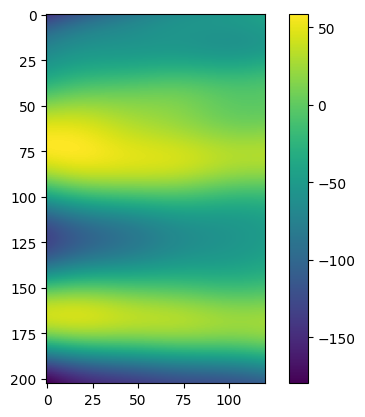

In [43]:
plt.imshow(vis_est.real)
plt.colorbar()

In [34]:
b_loaded=np.load('b_sys_past.npy')

In [35]:
vis_est=vis/b_loaded

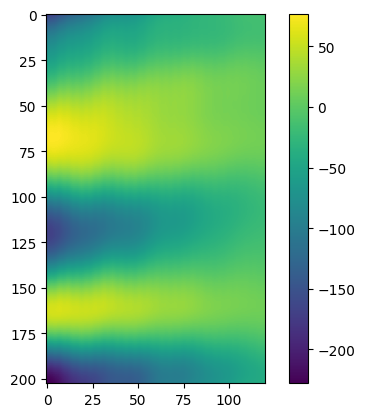

In [44]:
plt.imshow(vis.real)
plt.colorbar()

In [2]:
old_cov=np.load('test_data/eor-cov.npy')

In [3]:
uvd=UVData()
uvd.read('/Users/user/Documents/Codes/hydra_sys_project1/hydra-pspec-systematic-multiplicative/gauss_1_data/vis-eor.uvh5')
antpairpols = uvd.get_antpairpols()
vis=uvd.get_data(antpairpols[0])
freqs=uvd.freq_array[0]
lsts=uvd.lst_array

Telescope Hex37-14.6m is not in known_telescopes.


In [4]:
antpairpols[0]

(0, 0, 'xx')

In [12]:
len(freqs)

120

In [13]:
import hera_pspec as hp

# Each beam is defined over a frequency interval:
beam_freqs = np.linspace(100e6, 120e6, 120) # in Hz

# Create a new Gaussian beam object with full-width at half-max. of 0.1 radians
beam_gauss = hp.PSpecBeamGauss(fwhm=1, beam_freqs=beam_freqs)

# Create a new PSpecData object
ds = hp.PSpecData(dsets=[uvd], beam=beam_gauss)

# bls1 and bls2 are lists of tuples specifying baselines (antenna pairs)
# Here, we specify three baseline-pairs, i.e. bls1[0] x bls2[0],
# bls1[1] x bls2[1], and bls1[2] x bls2[2].
bls1 = [(0,0)]
bls2 = [(0,0)]

# Calculate cross-spectra of visibilities for baselines bls1[i] x bls2[i],
# where bls1 are the baselines to take from dataset 0 and bls2 are taken from
# dataset 1 (and i goes from 0..2). This is done for two spectral windows
# (freq. channel indexes between 300-400 and 600-721), with unity weights
# and a Blackman-Harris taper in each spectral window
uvp = ds.pspec(bls1, bls2, dsets=(0,0), spw_ranges=[(100, 110), (110, 120)],
               input_data_weight='identity', norm='I', taper='blackman-harris',
               verbose=True,pols='xx')


Setting spectral range: (100, 110)

Using polarization pair: ('xx', 'xx')

(bl1, bl2) pair: ((0, 0), (0, 0))
pol: (-5, -5)
  Building G...
  Building q_hat...
  Normalizing power spectrum...
  Computing and multiplying scalar...

Setting spectral range: (110, 120)

Using polarization pair: ('xx', 'xx')

(bl1, bl2) pair: ((0, 0), (0, 0))
pol: (-5, -5)
  Building G...
  Building q_hat...
  Normalizing power spectrum...
  Computing and multiplying scalar...


Casting complex values to real discards the imaginary part


In [14]:
# Key specifying desired spectral window, baseline-pair, and polarization pair
spw = 1
polpair = ('xx', 'xx')
blpair =((0,0),(0,0))
key = (spw, blpair, polpair)

# Get delay bins and power spectrum
dlys = uvp.get_dlys(spw)
ps = uvp.get_data(key)

In [29]:
# Build a list of all baseline-pairs in the UVPSpec object
# blpair_group = [[(0,0),(0,0)]]
blpair_groups = [[[(uvp.antnums_to_blpair((0, 0)), uvp.antnums_to_blpair((0, 0)))]]]

uvp_avg = uvp.average_spectra(blpair_groups=[[(0,0),(0,0)]], time_avg=True, inplace=False)

TypeError: 'int' object is not subscriptable

# Inspecting Airy beam covariance

In [30]:
eor_cov=np.load('test_data/eor-cov.npy')

In [31]:
type(eor_cov),eor_cov.shape

(numpy.ndarray, (120, 120))

Text(0.5, 1.0, 'Imaginary part')

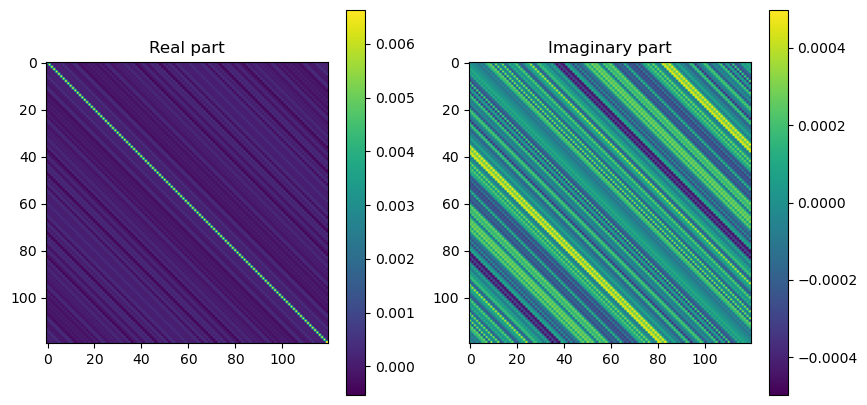

In [40]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
im0=ax[0].imshow(eor_cov.real)
ax[0].set_title("Real part")
plt.colorbar(im0)
im1=ax[1].imshow(eor_cov.imag)
plt.colorbar(im1)
ax[1].set_title("Imaginary part")

In [36]:
uvd.read('test_Data/vis-eor-fgs.uvh5')
antpairpols = uvd.get_antpairpols()
clean_vis=uvd.get_data(antpairpols[0])

eor_cov_new=np.outer(clean_vis,np.conjugate(clean_vis))

Telescope Hex37-14.6m is not in known_telescopes.


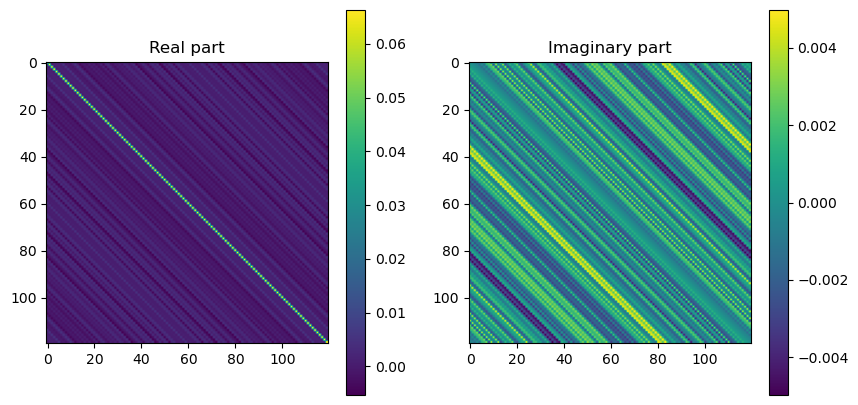

In [41]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
im0=ax[0].imshow(10*eor_cov.real)
ax[0].set_title("Real part")
plt.colorbar(im0)
im1=ax[1].imshow(10*eor_cov.imag)
ax[1].set_title("Imaginary part")
plt.colorbar(im1)

In [38]:
type(eor_cov_new),eor_cov_new.shape

(numpy.ndarray, (24360, 24360))